Kullback-Leibler (KL) divergence measures how much one probability distribution differs from another, serving as a key tool in machine learning for tasks like model evaluation and variational inference. It's asymmetric, meaning D_KL(P || Q) ≠ D_KL(Q || P) in general, and equals zero only when P = Q.

## Core Defination
Kullback-Leibler (KL) Divergence is a measure of "surprise." It tells you how much information is lost—or how much extra "cost" you incur—when you use a simplified or incorrect model (\(Q\)) to represent the reality (\(P\))


D
KL
 (P∥Q)=∑
x
 P(x)log
Q(x)
P(x)


### Theoretical Derivation
Start from the intuition of information theory. The entropy H(P) = -∑ P(x) log P(x) measures uncertainty in P. Cross-entropy H(P, Q) = -∑ P(x) log Q(x) measures uncertainty using Q's probabilities for P's events.

Subtracting gives:

D
KL
(
P
∥
Q
)
=
H
(
P
,
Q
)
−
H
(
P
)
=
∑
x
P
(
x
)
log
⁡
P
(
x
)
Q
(
x
)
D
KL
 (P∥Q)=H(P,Q)−H(P)=∑
x
 P(x)log
Q(x)
P(x)


Proof of non-negativity uses Jensen's inequality on the convex function f(t) = -log t:

D KL
(
P
∥
Q
)
\=
∑
x
P
(
x
)
log
⁡
P
(
x
)/
Q
(
x
)
\=
−
∑
x
P
(
x
)
log
⁡
Q
(
x
)
P
(
x
)
≥
−
log
⁡
(
∑
x
P
(
x
)
Q
(
x
)
P
(
x
)
)
=
−
log
⁡
1
\=
0

D
KL
 (P∥Q)=∑
x
 P(x)log
Q(x)
P(x)
 =−∑
x
 P(x)log
P(x)
Q(x)
 ≥−log(∑
x
 P(x)
P(x)
Q(x)
 )=−log1=0

Equality holds iff P(x) = Q(x) wherever P(x) > 0

Example Problem 1: Binary Distributions
Compare true distribution P = [0.7, 0.3] (success probabilities) with approximation Q = [0.6, 0.4].

Compute:

D
KL
(
P
∥
Q
)
=
0.7
log
⁡
0.7
0.6
+
0.3
log
⁡
0.3
0.4
≈
0.7
×
0.151
+
0.3
×
(
−
0.288
)
≈
0.106
−
0.086
=
0.02
D
KL
 (P∥Q)=0.7log
0.6
0.7
 +0.3log
0.4
0.3
 ≈0.7×0.151+0.3×(−0.288)≈0.106−0.086=0.02

Reverse: D_KL(Q || P) ≈ 0.024 (slightly higher, showing asymmetry).

In short i can tell kl divergence say how much cost will occur if we consider Q as model to represent P (Original distribution)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
color_pal = sns.color_palette()
plt.style.use("ggplot")

In [2]:
x = np.linspace(-3,3,1000)

In [3]:
samp_1 = np.random.normal(loc=-1,scale=1,size=(1000))
samp_2 = np.random.normal(loc=2,scale=1,size=(1000))

In [4]:
samp_1.shape,samp_2.shape

((1000,), (1000,))

In [13]:
pdf_p = stats.norm.pdf(x, loc=-1.0, scale=1.0)
pdf_q = stats.norm.pdf(x, loc=2.0, scale=1.0)
pdf_p.shape , pdf_q.shape

((1000,), (1000,))

In [15]:
epsilon = 1e-10
pointwise_kl = pdf_p * np.log((pdf_p + epsilon) / (pdf_q + epsilon))
pointwise_kl.shape

(1000,)

In [17]:
pointwise_kl

array([ 3.43108155e-03,  3.46652435e-03,  3.50219373e-03,  3.53808921e-03,
        3.57421027e-03,  3.61055636e-03,  3.64712689e-03,  3.68392123e-03,
        3.72093874e-03,  3.75817871e-03,  3.79564044e-03,  3.83332314e-03,
        3.87122603e-03,  3.90934828e-03,  3.94768900e-03,  3.98624731e-03,
        4.02502225e-03,  4.06401285e-03,  4.10321809e-03,  4.14263692e-03,
        4.18226824e-03,  4.22211094e-03,  4.26216383e-03,  4.30242573e-03,
        4.34289538e-03,  4.38357150e-03,  4.42445278e-03,  4.46553785e-03,
        4.50682533e-03,  4.54831376e-03,  4.59000168e-03,  4.63188758e-03,
        4.67396988e-03,  4.71624701e-03,  4.75871733e-03,  4.80137916e-03,
        4.84423078e-03,  4.88727045e-03,  4.93049637e-03,  4.97390669e-03,
        5.01749956e-03,  5.06127304e-03,  5.10522519e-03,  5.14935400e-03,
        5.19365743e-03,  5.23813341e-03,  5.28277982e-03,  5.32759449e-03,
        5.37257522e-03,  5.41771977e-03,  5.46302586e-03,  5.50849115e-03,
        5.55411328e-03,  

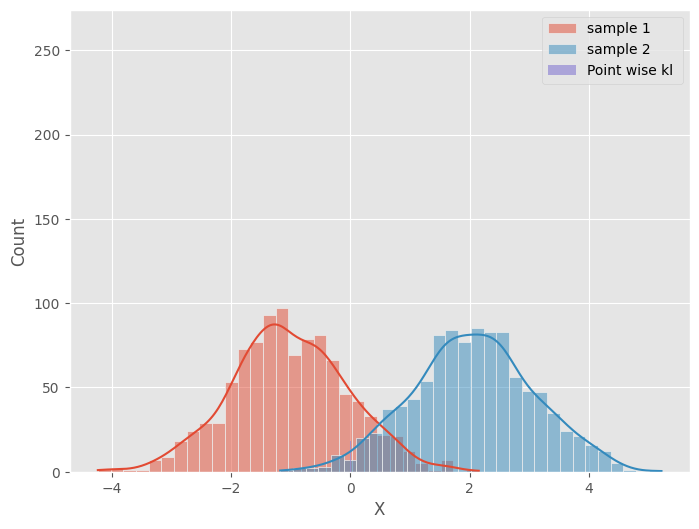

In [20]:
plt.figure(figsize=(8,6))

sns.histplot(samp_1,bins=30,kde=True,label="sample 1")
sns.histplot(samp_2,bins=30,kde=True,label="sample 2")
# plt.plot(x, pointwise_kl, label='Pointwise KL Contribution', color='red', lw=2)
# plt.fill_between(x, pointwise_kl, color='red', alpha=0.2)
sns.histplot(pointwise_kl,bins=30,label="Point wise kl ")
plt.xlabel("X")
plt.legend(loc="upper right")
plt.show()

In [21]:
pdf_p /= np.sum(pdf_p)
pdf_q /= np.sum(pdf_q)

# 4. Calculate KL Divergence
kl_pq = stats.entropy(pdf_p, pdf_q)
print(f"The extra cost is: {kl_pq:.4f} nats")

The extra cost is: 4.1867 nats


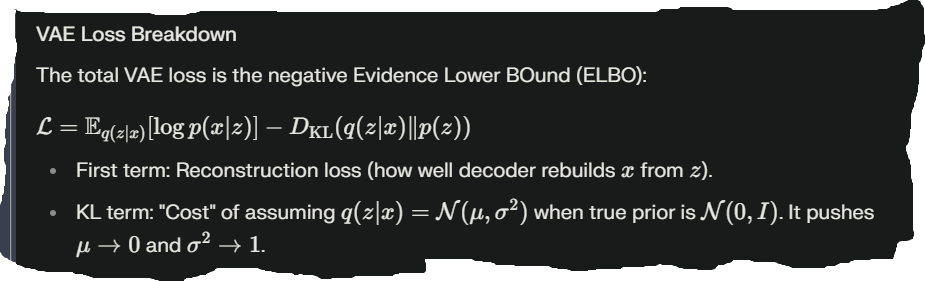

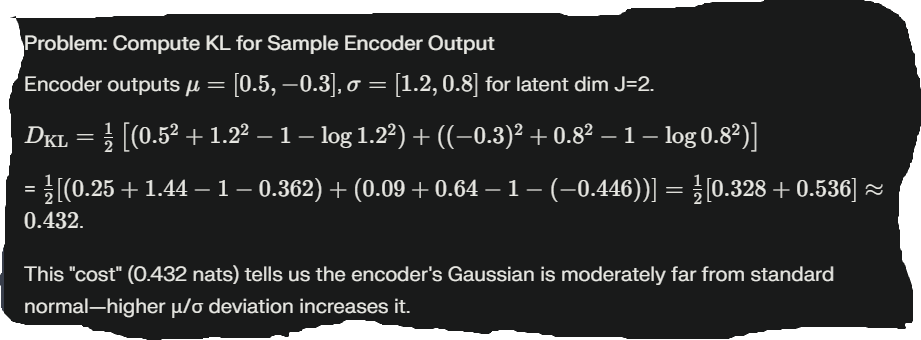

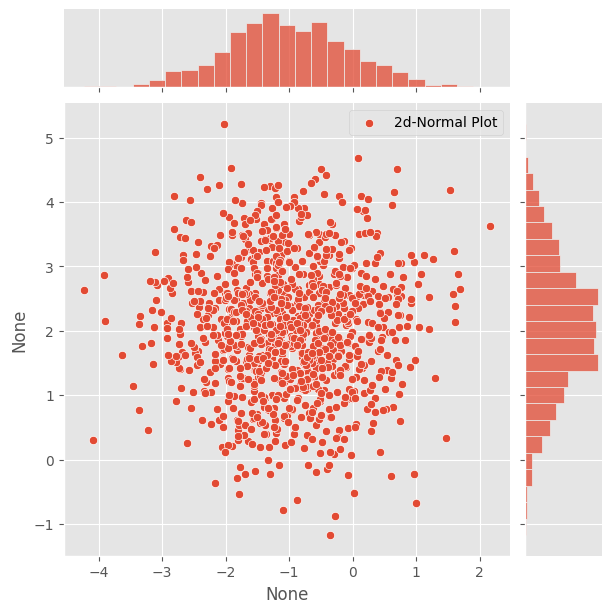

In [24]:
sns.jointplot(x=samp_1,y=samp_2,label="2d-Normal Plot")

In [25]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

# 1. Setup sample space and distributions
x = np.linspace(-5, 5, 500)
p = stats.norm.pdf(x, loc=0, scale=1)      # Truth (P)
q = stats.norm.pdf(x, loc=0.6, scale=1.4)  # Model (Q)

# Normalize for discrete calculation
p_norm = p / np.sum(p)
q_norm = q / np.sum(q)

# 2. Calculate Pointwise KL Divergence
epsilon = 1e-10
pointwise_kl = p_norm * np.log((p_norm + epsilon) / (q_norm + epsilon))
total_kl = np.sum(pointwise_kl)

# 3. Create Joint-style Subplots
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.1,
                    subplot_titles=("Distribution Comparison", "Pointwise KL Divergence (The Cost)"))

# Top Plot: Distributions
fig.add_trace(go.Scatter(x=x, y=p, name='True P(x)', fill='tozeroy', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=q, name='Model Q(x)', fill='tozeroy', line=dict(color='orange', dash='dash')), row=1, col=1)

# Bottom Plot: KL Cost
fig.add_trace(go.Scatter(x=x, y=pointwise_kl, name='KL Contribution', fill='tozeroy', line=dict(color='red')), row=2, col=1)

# Update Layout for a "Joint Plot" feel
fig.update_layout(height=700, title_text=f"Total KL Divergence: {total_kl:.4f} Nats", showlegend=True)
fig.update_yaxes(title_text="Density", row=1, col=1)
fig.update_yaxes(title_text="Cost (Pointwise KL)", row=2, col=1)
fig.update_xaxes(title_text="Value (x)", row=2, col=1)

fig.show()
